# Part C

# Imports

In [1]:
import os
import random
import torch
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from torchvision import models
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F

# Data Visualization

Using device: cuda
[cats] cat.7945.jpg - Raw Size: (500, 374)
[cats] cat.2881.jpg - Raw Size: (500, 243)
[cats] cat.12030.jpg - Raw Size: (500, 329)
[cats] cat.7806.jpg - Raw Size: (176, 141)
[dogs] dog.4521.jpg - Raw Size: (319, 240)
[dogs] dog.6283.jpg - Raw Size: (309, 500)
[dogs] dog.6219.jpg - Raw Size: (499, 375)
[dogs] dog.10575.jpg - Raw Size: (499, 375)


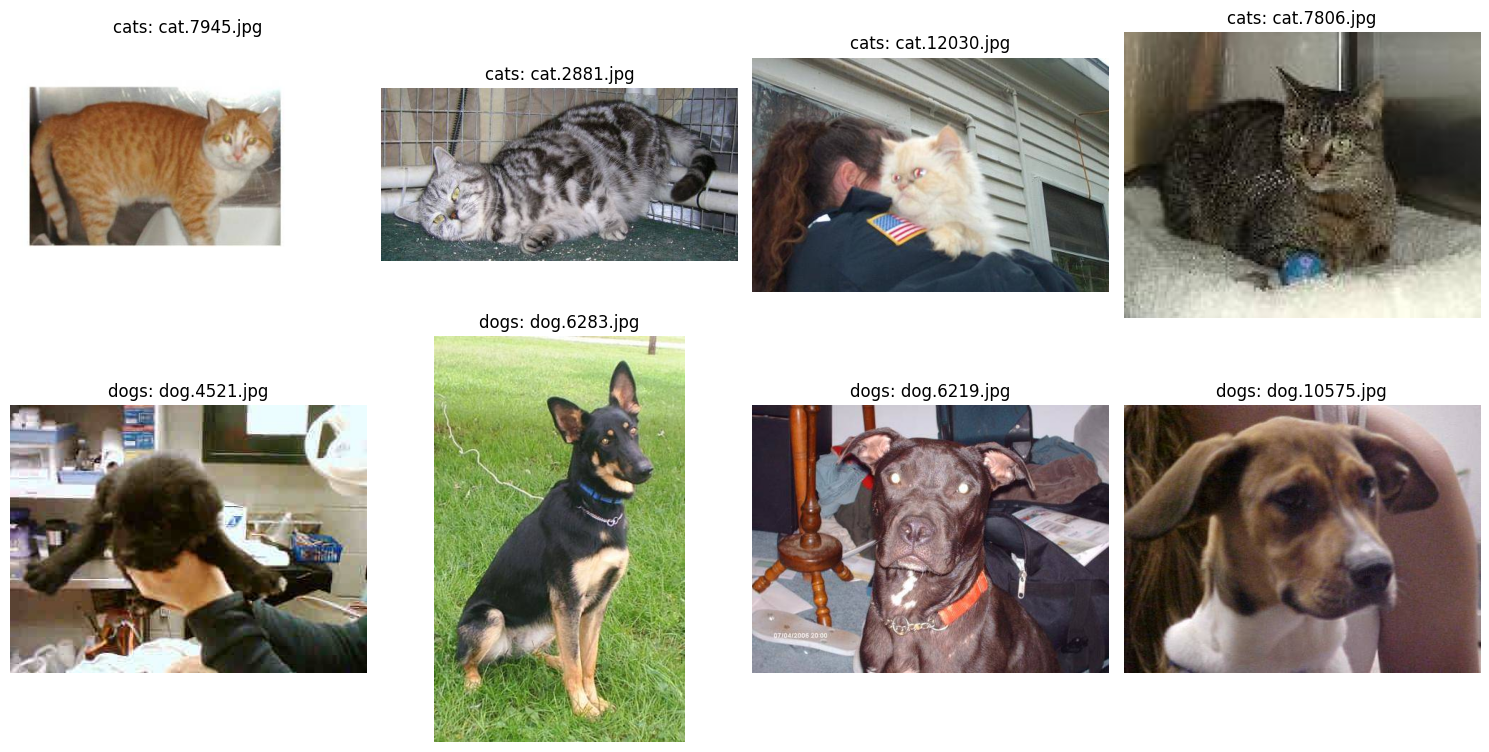

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
data_path = '../415-Final-Project/ecse-415-winter-2026-dog-vs-cat-classification/train/train'

def show_random_samples(data_dir, num_samples=4):
    classes = ['cats', 'dogs']
    
    plt.figure(figsize=(15, 8))
    for i, clas in enumerate(classes):
        cls_dir = os.path.join(data_dir, clas)

        # file names
        images = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
        
        # get a random sample
        samples = random.sample(images, num_samples)
        
        for j, img_name in enumerate(samples):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            
            # 1, 2, 3, 4 for cats; 5, 6, 7, 8 for dogs
            plt.subplot(2, num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{clas}: {img_name}")
            plt.axis('off')

            print(f"[{clas}] {img_name} - Raw Size: {img.size}")
            
    plt.tight_layout()
    plt.show()

show_random_samples(data_path)

In [3]:
cat_count = len(os.listdir(os.path.join(data_path, 'cats')))
dog_count = len(os.listdir(os.path.join(data_path, 'dogs')))

print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")
print(f"Total: {cat_count + dog_count}")


Cats: 10021
Dogs: 9979
Total: 20000


# Chossing the best data augmentation

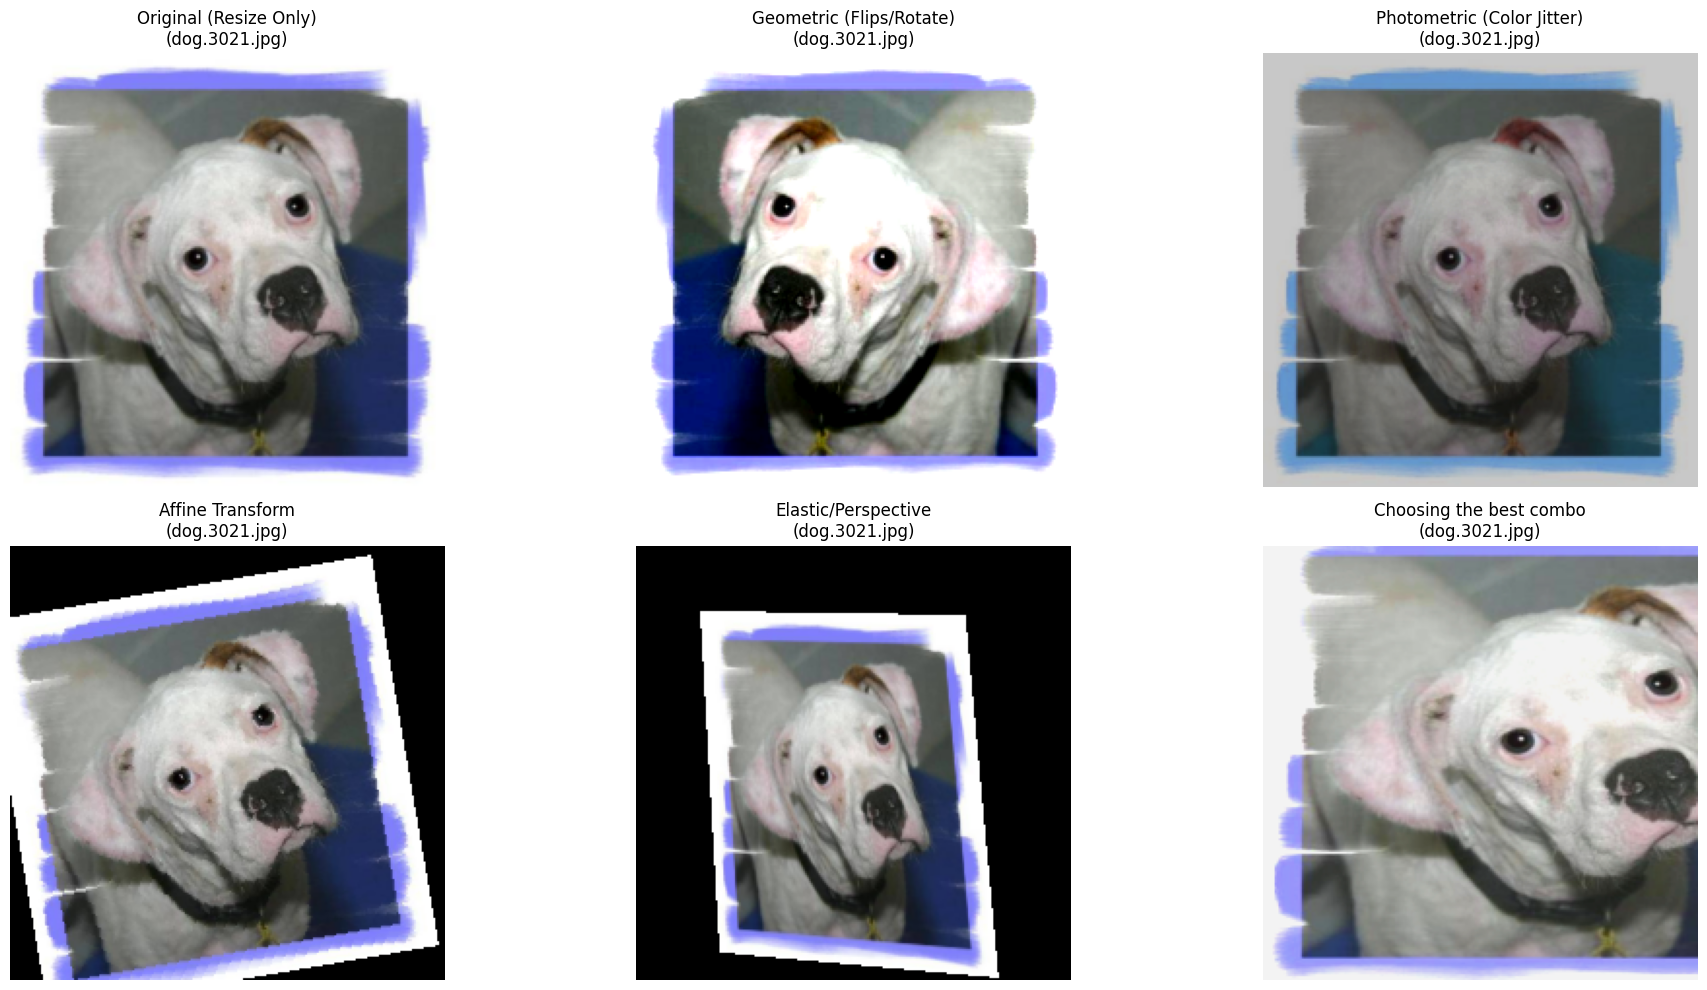

In [4]:
def get_random_img_pth(dir_path):
    cls = random.choice(['cats', 'dogs'])
    cls_dir = os.path.join(dir_path, cls)
    img_name = random.choice(os.listdir(cls_dir))
    return os.path.join(cls_dir, img_name)

# try different data augmentations and visualize the results and then pick the best one for training
augmentations = {
    "Original (Resize Only)": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    
    "Geometric (Flips/Rotate)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0), # Forced on for visualization
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)
    ]),
    
    "Photometric (Color Jitter)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ]),
    
    "Affine Transform": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2))
    ]),
    
    "Elastic/Perspective": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomPerspective(distortion_scale=0.5, p=1.0)
    ]),
    
    "Choosing the best combo": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2)
    ])
}

img_path = get_random_img_pth(data_path)
img = Image.open(img_path).convert('RGB')

plt.figure(figsize=(20, 10))

for i, (name, policy) in enumerate(augmentations.items()):
    augmented_img = policy(img)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_img)
    plt.title(f"{name}\n({img_path.split(os.sep)[-1]})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# chosen transforms for training and validation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

# blow up the pic to 256 first and then resize to 224 to match training set 
val_transform = transforms.Compose([
    transforms.Resize((256, 256)), # resize a bit larger
    transforms.CenterCrop(224),    # crop the exact center
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# split 80/20
full_dataset_train = datasets.ImageFolder(data_path, transform=train_transform)
full_dataset_val = datasets.ImageFolder(data_path, transform=val_transform)

train_size = int(0.8 * len(full_dataset_train))
val_size = len(full_dataset_train) - train_size

np.random.seed(42)
indices = np.random.permutation(len(full_dataset_train)).tolist()

#seed = torch.Generator().manual_seed(42)
train_dataset = Subset(full_dataset_train, indices[:train_size])
val_dataset = Subset(full_dataset_val, indices[train_size:])

# loading the data into dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Total train batches: {len(train_loader)}")
print(f"Total validation batches: {len(val_loader)}")


Total train batches: 500
Total validation batches: 125


# Training EfficientNet on the 80% and generating confusion matrix on the 20% validation set

Training EfficientNetV2-M on 80% split
Epoch 1/5, Train Loss: 0.0897, Val Loss 0.0182, Val Acc: 0.9935
Epoch 2/5, Train Loss: 0.0618, Val Loss 0.0143, Val Acc: 0.9955
Epoch 3/5, Train Loss: 0.0593, Val Loss 0.0171, Val Acc: 0.9938
Epoch 4/5, Train Loss: 0.0564, Val Loss 0.0133, Val Acc: 0.9935
Epoch 5/5, Train Loss: 0.0578, Val Loss 0.0150, Val Acc: 0.9942


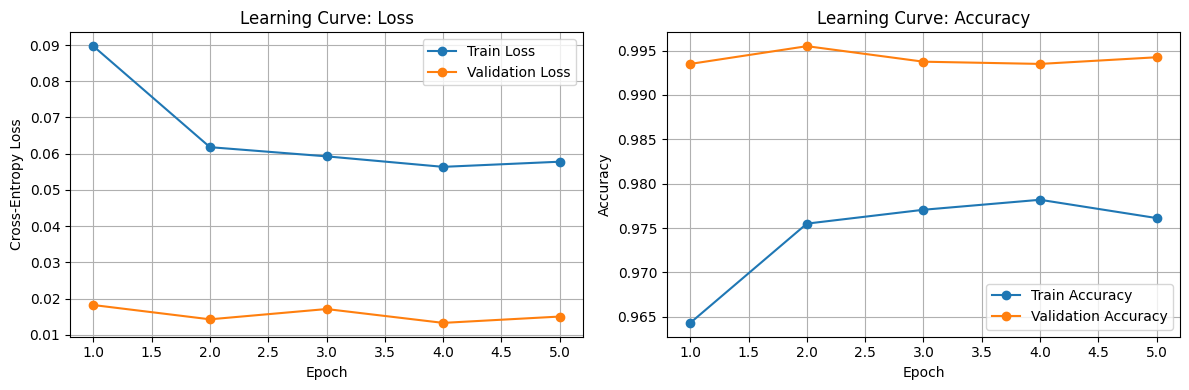

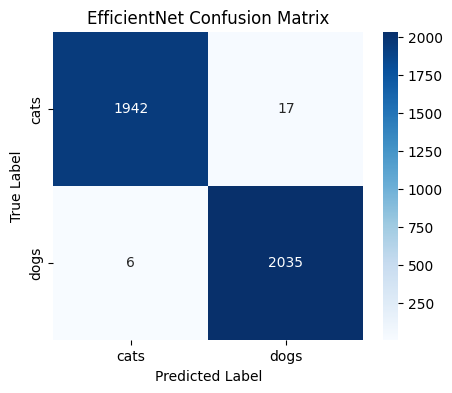

In [6]:
print("Training EfficientNetV2-M on 80% split")

model_eff = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
model_eff.classifier[1] = nn.Linear(model_eff.classifier[1].in_features, 2)
model_eff = model_eff.to(device)

# added weight decay to prevent overfitting
optimizer_eff = optim.Adam(model_eff.parameters(), lr=0.0001, weight_decay=1e-4) 
criterion = nn.CrossEntropyLoss()

# lists to hold curve data
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 5
for epoch in range(epochs):
    # training
    model_eff.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_eff.zero_grad()
        
        outputs = model_eff(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_eff.step()
        
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    # validating at each epoch
    model_eff.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model_eff(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
            # for confusion matrix
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # stroing for plotting 
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, Val Loss {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# loss curve, making sure no overfitting
ax1.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='o')
ax1.set_title('Learning Curve: Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True)

# accuracy curve
ax2.plot(range(1, epochs+1), train_accs, label='Train Accuracy', marker='o')
ax2.plot(range(1, epochs+1), val_accs, label='Validation Accuracy', marker='o')
ax2.set_title('Learning Curve: Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.dataset.classes, yticklabels=train_dataset.dataset.classes)
plt.title("EfficientNet Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

torch.save(model_eff.state_dict(), 'efficientnet_80_best.pth')

# Training ConvNeXt on the 80% and generating confusion matrix on the 20% validation set

In [7]:
print("Training ConvNeXt-Small in 80% Split")

torch.backends.cudnn.benchmark = True

model_conv = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
model_conv.classifier[2] = nn.Linear(model_conv.classifier[2].in_features, 2)
model_conv = model_conv.to(device)

optimizer_conv = optim.Adam(model_conv.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

train_losses_c, val_losses_c = [], []
train_accs_c, val_accs_c = [], []

epochs = 5
best_val_acc = 0.0

for epoch in range(epochs):
    model_conv.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_conv.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model_conv(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_conv)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total

    model_conv.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds_c, all_labels_c = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                outputs = model_conv(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            all_preds_c.extend(preds.cpu().numpy())
            all_labels_c.extend(labels.cpu().numpy())

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    train_losses_c.append(epoch_train_loss)
    val_losses_c.append(epoch_val_loss)
    train_accs_c.append(epoch_train_acc)
    val_accs_c.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model_conv.state_dict(), 'convnext_80_best.pth')

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_train_loss:.4f}, "
          f"Train Acc: {epoch_train_acc:.4f}, Val Loss: {epoch_val_loss:.4f}, "
          f"Val Acc: {epoch_val_acc:.4f}")

Training ConvNeXt-Small in 80% Split


C:\Users\ahmal\AppData\Local\Temp\ipykernel_22616\3429707098.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\ahmal\AppData\Local\Temp\ipykernel_22616\3429707098.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\ahmal\AppData\Local\Temp\ipykernel_22616\3429707098.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/5, Train Loss: 0.0935, Train Acc: 0.9611, Val Loss: 0.0117, Val Acc: 0.9960
Epoch 2/5, Train Loss: 0.0710, Train Acc: 0.9694, Val Loss: 0.0163, Val Acc: 0.9958
Epoch 3/5, Train Loss: 0.0752, Train Acc: 0.9685, Val Loss: 0.0147, Val Acc: 0.9952
Epoch 4/5, Train Loss: 0.0698, Train Acc: 0.9713, Val Loss: 0.0184, Val Acc: 0.9935
Epoch 5/5, Train Loss: 0.0663, Train Acc: 0.9717, Val Loss: 0.0220, Val Acc: 0.9920


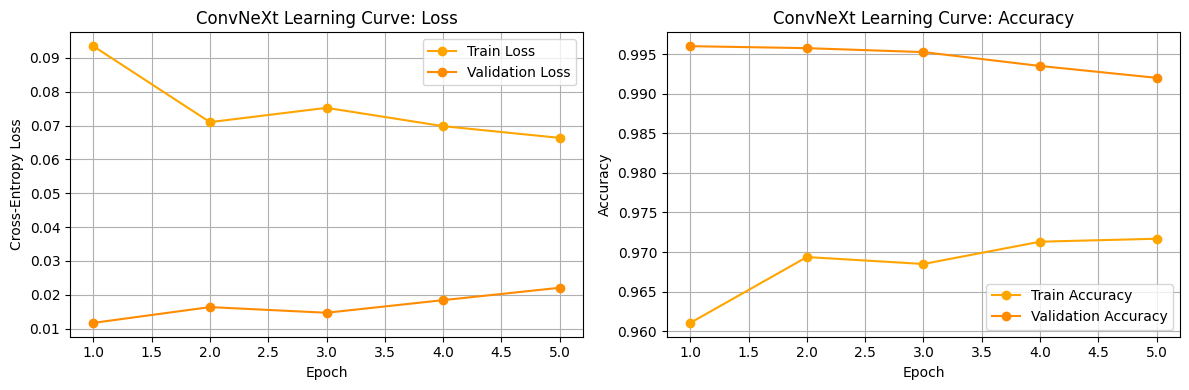

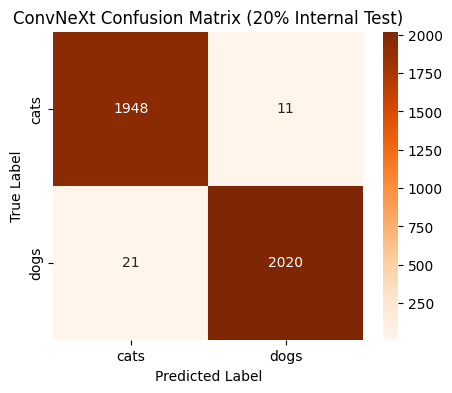

In [8]:
# plotting 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# loss curve to check any overfitting
ax1.plot(range(1, epochs+1), train_losses_c, label='Train Loss', marker='o', color='orange')
ax1.plot(range(1, epochs+1), val_losses_c, label='Validation Loss', marker='o', color='darkorange')
ax1.set_title('ConvNeXt Learning Curve: Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()
ax1.grid(True)

# accuracy curve
ax2.plot(range(1, epochs+1), train_accs_c, label='Train Accuracy', marker='o', color='orange')
ax2.plot(range(1, epochs+1), val_accs_c, label='Validation Accuracy', marker='o', color='darkorange')
ax2.set_title('ConvNeXt Learning Curve: Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.tight_layout()

plt.show()

# the confuion matrix
cm_conv = confusion_matrix(all_labels_c, all_preds_c)
plt.figure(figsize=(5,4))
sns.heatmap(cm_conv, annot=True, fmt='d', cmap='Oranges', xticklabels=train_dataset.dataset.classes, yticklabels=train_dataset.dataset.classes)
plt.title("ConvNeXt Confusion Matrix (20% Internal Test)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Confusion Matrix with Ensemble on 20% Validation Set


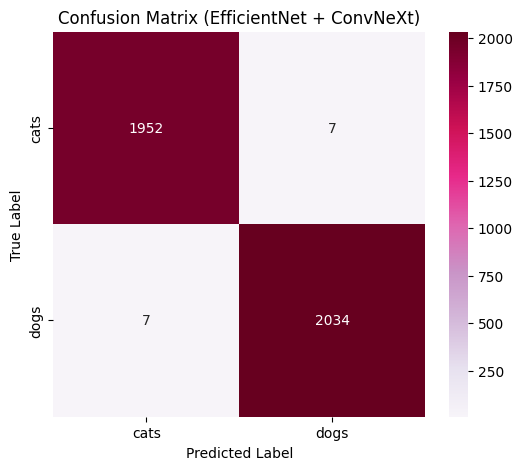

In [9]:
print("Confusion Matrix with Ensemble on 20% Validation Set")
model_eff.eval()
model_conv.eval()

ensemble_preds, ensemble_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        # get outputs from both models
        out_eff = model_eff(images)
        out_conv = model_conv(images)
        
        # convert to probabilities using Softmax
        prob_eff = F.softmax(out_eff, dim=1)
        prob_conv = F.softmax(out_conv, dim=1)
        
        # average the probabilities
        avg_probs = (prob_eff + prob_conv) / 2.0
        
        # final prediction from the averaged probabilities
        final_preds = torch.argmax(avg_probs, dim=1)
        
        ensemble_preds.extend(final_preds.cpu().numpy())
        ensemble_labels.extend(labels.cpu().numpy())

# ensemble confusion matrix
cm_ensemble = confusion_matrix(ensemble_labels, ensemble_preds)
plt.figure(figsize=(6, 5))

sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='PuRd', 
            xticklabels=val_dataset.dataset.classes, 
            yticklabels=val_dataset.dataset.classes)

plt.title("Confusion Matrix (EfficientNet + ConvNeXt)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Hunting for a misclassification...


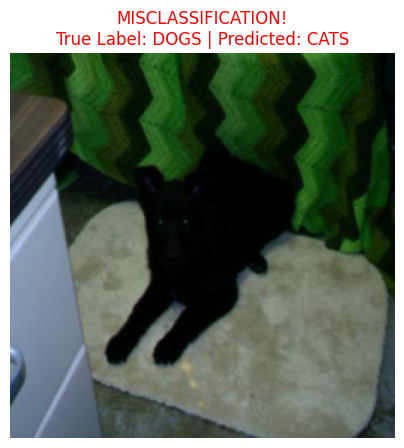

In [ ]:
print("Hunting for a misclassification...")
model_eff.eval()
model_conv.eval()

# We need this to "undo" the ImageNet normalization so the image doesn't look deep-fried when we plot it
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

found = False
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        out_eff = model_eff(images)
        out_conv = model_conv(images)
        
        prob_eff = F.softmax(out_eff, dim=1)
        prob_conv = F.softmax(out_conv, dim=1)
        
        avg_probs = (prob_eff + prob_conv) / 2.0
        final_preds = torch.argmax(avg_probs, dim=1)
        
        # Find the indices in this batch where the predicted label does NOT match the true label
        mismatches = (final_preds != labels).nonzero(as_tuple=True)[0]
        
        if len(mismatches) > 0:
            # Grab the very first mistake we found!
            mistake_idx = mismatches[0]
            true_lbl = labels[mistake_idx].item()
            pred_lbl = final_preds[mistake_idx].item()
            
            # Format the image to be printed by Matplotlib
            img_tensor = images[mistake_idx].cpu()
            img_tensor = inv_normalize(img_tensor) # Undo the normalization
            img_numpy = img_tensor.permute(1, 2, 0).numpy() # (C,H,W) to (H,W,C)
            img_numpy = np.clip(img_numpy, 0, 1) # Make sure colors are bounded perfectly
            
            # Print it out
            classes = val_dataset.dataset.classes
            plt.figure(figsize=(5, 5))
            plt.imshow(img_numpy)
            plt.title(f"MISCLASSIFICATION!\nTrue Label: {classes[true_lbl].upper()} | Predicted: {classes[pred_lbl].upper()}", color='red')
            plt.axis('off')
            plt.show()
            
            found = True
            break # We only need one example, so we break/kill the loop instantly!

if not found:
    print("Zero mistakes found in the validation set!")

# TTA ensemble of EfficientNet and ConvNeXt

In [10]:
class KaggleTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.image_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
        self.test_dir = test_dir
        self.transform = transform

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        image = Image.open(os.path.join(self.test_dir, img_name)).convert('RGB')
        
        # return the raw PIL image
        return image, img_name.split('.')[0]

# TTA augments
normal_transform = transforms.Compose([
    transforms.Resize((256, 256)), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

flipped_transform = transforms.Compose([
    transforms.Resize((256, 256)), transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dir = '../415-Final-Project/ecse-415-winter-2026-dog-vs-cat-classification/test/test'

def tta_collate_fn(batch):
    images, ids = zip(*batch)
    return list(images), list(ids)

# using batch_size 1 because of TTA
test_dataset = KaggleTestDataset(test_dir)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=tta_collate_fn)

model_eff.eval()
model_conv.eval()
results = []

print("Running TTA Ensemble:")
with torch.no_grad():
    for i, (image_tuple, image_id) in enumerate(test_loader):

        # image_tuple is a tuple of PIL images, we need the original
        raw_image = image_tuple[0] 
        img_id = image_id[0]
        
        # generate two TTA augmentations
        img_normal = normal_transform(raw_image).unsqueeze(0).to(device)
        img_flipped = flipped_transform(raw_image).unsqueeze(0).to(device)
        
        # first aug: normal
        eff_out_norm = F.softmax(model_eff(img_normal), dim=1)
        
        conv_out_norm = F.softmax(model_conv(img_normal), dim=1)
        
        # 2nd aug: flipped
        eff_out_flip = F.softmax(model_eff(img_flipped), dim=1)
        conv_out_flip = F.softmax(model_conv(img_flipped), dim=1)
        
        # ensemble avg: (Eff_N + Conv_N + Eff_F + Conv_F) / 4
        avg_probs = (eff_out_norm + conv_out_norm + eff_out_flip + conv_out_flip) / 4.0
        
        final_pred = torch.argmax(avg_probs, dim=1).item()
        
        results.append({'id': img_id, 'label': final_pred})
        
        if (i+1) % 500 == 0:
            print(f"Processed {i+1}/{len(test_loader)}")

df_sub = pd.DataFrame(results)
df_sub['id'] = pd.to_numeric(df_sub['id'])
df_sub = df_sub.sort_values('id')
df_sub.to_csv('FINAL_ultimate_ensemble_submission.csv', index=False)
print("Done")


Running TTA Ensemble:
Processed 500/5000
Processed 1000/5000
Processed 1500/5000
Processed 2000/5000
Processed 2500/5000
Processed 3000/5000
Processed 3500/5000
Processed 4000/5000
Processed 4500/5000
Processed 5000/5000
Done
